In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

historical = pd.read_csv("MPS_Borough_Level_Crime_Historical.csv")
recent = pd.read_csv("MPS_Borough_Level_Crime_Recent_24_month.csv")
newest = pd.read_csv("MPS_Borough_Level_Crime _Most_Recent_24_months_new.csv")

id_cols_old = ["MajorText", "MinorText", "BoroughName"]
hist_long = historical.melt(id_vars=id_cols_old, var_name="YearMonth", value_name="CrimeCount")
recent_long = recent.melt(id_vars=id_cols_old, var_name="YearMonth", value_name="CrimeCount")

id_cols_new = ["Group", "SubGroup", "BOCU"]
newest_long = newest.melt(id_vars=id_cols_new, var_name="YearMonth", value_name="CrimeCount")
newest_long = newest_long.rename(columns={"BOCU": "BoroughName", "Group": "MajorText", "SubGroup": "MinorText"})

crime = pd.concat([hist_long, recent_long, newest_long], ignore_index=True)

not_boroughs = ["Unknown", "London Heathrow and London City Airports"]
crime = crime[~crime["BoroughName"].isin(not_boroughs)]
crime["Date"] = pd.to_datetime(crime["YearMonth"], format="%Y%m")
crime = crime.sort_values("Date").drop_duplicates(subset=["BoroughName", "MajorText", "MinorText", "Date"], keep="last")

burglary_rename = {
    "DOMESTIC BURGLARY": "RESIDENTIAL BURGLARY",
    "RES BURGLARY OF A HOME": "RESIDENTIAL BURGLARY",
    "RES BURGLARY OF UNCONNECTED BUILDING": "RESIDENTIAL BURGLARY",
    "BURGLARY - RESIDENTIAL": "RESIDENTIAL BURGLARY",
}
crime["MinorText"] = crime["MinorText"].replace(burglary_rename)

categories = sorted(crime["MajorText"].unique())
print("Number of major categories:", len(categories))
print(categories)

Number of major categories: 13
['ARSON AND CRIMINAL DAMAGE', 'BURGLARY', 'DRUG OFFENCES', 'FRAUD AND FORGERY', 'MISCELLANEOUS CRIMES AGAINST SOCIETY', 'NFIB FRAUD', 'POSSESSION OF WEAPONS', 'PUBLIC ORDER OFFENCES', 'ROBBERY', 'SEXUAL OFFENCES', 'THEFT', 'VEHICLE OFFENCES', 'VIOLENCE AGAINST THE PERSON']


In [2]:
category_results = []

for category in categories:
    if category == "NFIB FRAUD":
        continue  

    cat_series = crime[crime["MajorText"] == category].groupby("Date")["CrimeCount"].sum().sort_index()
    cat_series = cat_series.asfreq("MS")

    train = cat_series[:"2026-02-01"]
    test = cat_series["2026-03-01":"2026-06-01"]

    try:
        model = SARIMAX(train, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
        fitted = model.fit(disp=False)
        forecast = fitted.get_forecast(steps=4).predicted_mean

        pct_error = np.mean(np.abs(test.values - forecast.values) / test.values) * 100

        category_results.append({
            "Category": category,
            "Avg_Monthly_Crime": round(test.mean()),
            "Validation_Pct_Error": round(pct_error, 1)
        })
        print(f"{category}: {pct_error:.1f}% error")

    except Exception as e:
        print(f"{category}: FAILED - {e}")

category_df = pd.DataFrame(category_results).sort_values("Avg_Monthly_Crime", ascending=False)
print()
print(category_df.to_string(index=False))

ARSON AND CRIMINAL DAMAGE: 4.6% error
BURGLARY: 5.2% error
DRUG OFFENCES: 10.8% error
FRAUD AND FORGERY: inf% error
MISCELLANEOUS CRIMES AGAINST SOCIETY: 4.2% error
POSSESSION OF WEAPONS: 16.7% error
PUBLIC ORDER OFFENCES: 36.5% error
ROBBERY: 8.0% error
SEXUAL OFFENCES: 3.7% error
THEFT: 6.0% error
VEHICLE OFFENCES: 7.8% error
VIOLENCE AGAINST THE PERSON: 5.8% error

                            Category  Avg_Monthly_Crime  Validation_Pct_Error
                               THEFT              23725                   6.0
         VIOLENCE AGAINST THE PERSON              22216                   5.8
                    VEHICLE OFFENCES               6970                   7.8
               PUBLIC ORDER OFFENCES               5121                  36.5
           ARSON AND CRIMINAL DAMAGE               4584                   4.6
                            BURGLARY               3691                   5.2
                       DRUG OFFENCES               3616                  10.8
     

In [3]:
public_order = crime[crime["MajorText"] == "PUBLIC ORDER OFFENCES"].groupby("Date")["CrimeCount"].sum().sort_index()
print(public_order.tail(10))

Date
2025-09-01    7669
2025-10-01    7712
2025-11-01    7083
2025-12-01    6819
2026-01-01    6352
2026-02-01    6257
2026-03-01    4764
2026-04-01    4713
2026-05-01    5408
2026-06-01    5598
Name: CrimeCount, dtype: int64


In [4]:
fraud = crime[crime["MajorText"] == "FRAUD AND FORGERY"].groupby("Date")["CrimeCount"].sum().sort_index()
print(fraud.tail(8))

Date
2025-11-01    7
2025-12-01    0
2026-01-01    4
2026-02-01    0
2026-03-01    4
2026-04-01    5
2026-05-01    0
2026-06-01    7
Name: CrimeCount, dtype: int64


In [5]:
top_boroughs = ["Westminster", "Newham", "Southwark", "Camden", "Lambeth"]
top_categories = ["THEFT", "VIOLENCE AGAINST THE PERSON", "BURGLARY", "VEHICLE OFFENCES", "DRUG OFFENCES"]

detailed_results = []

for borough in top_boroughs:
    for category in top_categories:
        subset = crime[(crime["BoroughName"] == borough) & (crime["MajorText"] == category)]
        series = subset.groupby("Date")["CrimeCount"].sum().sort_index()
        series = series.asfreq("MS")

        train = series[:"2026-02-01"]
        test = series["2026-03-01":"2026-06-01"]

        try:
            model = SARIMAX(train, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
            fitted = model.fit(disp=False)
            forecast = fitted.get_forecast(steps=4).predicted_mean

            pct_error = np.mean(np.abs(test.values - forecast.values) / (test.values + 1)) * 100

            detailed_results.append({
                "Borough": borough,
                "Category": category,
                "Avg_Monthly": round(test.mean(), 1),
                "Pct_Error": round(pct_error, 1)
            })
        except Exception as e:
            print(f"{borough} - {category}: FAILED - {e}")

detailed_df = pd.DataFrame(detailed_results)
print(detailed_df.to_string(index=False))
print()
print("Total combinations:", len(detailed_df))

    Borough                    Category  Avg_Monthly  Pct_Error
Westminster                       THEFT       3157.0       16.9
Westminster VIOLENCE AGAINST THE PERSON        924.5        4.2
Westminster                    BURGLARY        195.2       21.6
Westminster            VEHICLE OFFENCES        204.2       19.2
Westminster               DRUG OFFENCES        236.0       14.5
     Newham                       THEFT       1126.0        2.9
     Newham VIOLENCE AGAINST THE PERSON        999.5        2.8
     Newham                    BURGLARY        160.8       16.3
     Newham            VEHICLE OFFENCES        397.5       10.3
     Newham               DRUG OFFENCES        180.0       17.3
  Southwark                       THEFT       1456.0        3.6
  Southwark VIOLENCE AGAINST THE PERSON        807.8        4.8
  Southwark                    BURGLARY        191.0        6.8
  Southwark            VEHICLE OFFENCES        213.2       24.8
  Southwark               DRUG OFFENCES 

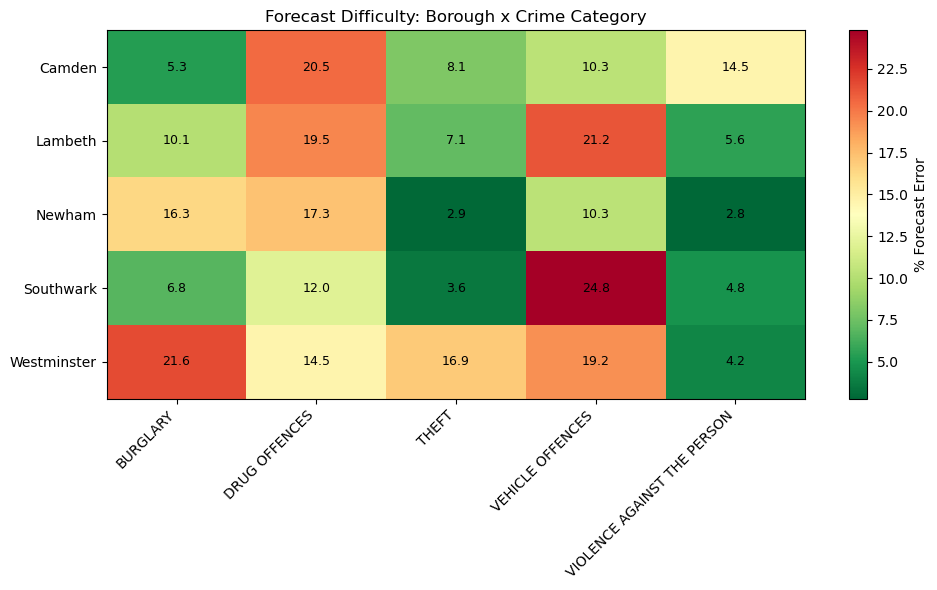

Saved!


In [6]:
category_df.to_csv("data/category_forecast_validation.csv", index=False)
detailed_df.to_csv("data/borough_category_forecast_validation.csv", index=False)

import matplotlib.pyplot as plt

pivot = detailed_df.pivot(index="Borough", columns="Category", values="Pct_Error")

plt.figure(figsize=(10, 6))
plt.imshow(pivot, cmap="RdYlGn_r", aspect="auto")
plt.colorbar(label="% Forecast Error")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Forecast Difficulty: Borough x Crime Category")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f"{pivot.iloc[i,j]:.1f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/18_borough_category_heatmap.png", dpi=150)
plt.show()

print("Saved!")